# <center>**Linear Regression**</center>

## Algorithms

1. **Closed form**

2. **Gradient descent**

3. **Stochastic gradient descent**

4. **Mini batch**


---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linear_regression import Linear_Regression
from metrics import MSE, RMSE

# importing dataset
path = '../data/happiness2016.csv'

df = pd.read_csv(path)

#### Checking data

In [2]:
df.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    str    
 1   Region                         157 non-null    str    
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    float64
dtypes

#### Dataset Description

Dataset represents factors that have more or less influence on people's happiness in 157 countries in 2015. Each row corresponds to one country.

* **Country** – country name
* **Region** – region of the country
* **Happiness Rank** – country's rank according to the happiness score
* **Happiness Score** – average happiness score (0–10)
* **Lower Confidence Interval** – lower bound of the confidence interval for the happiness score
* **Upper Confidence Interval** – upper bound of the confidence interval for the happiness score
* **Economy (GDP per Capita)** – GDP contribution to the happiness score
* **Family** – family support contribution to the score
* **Health (Life Expectancy)** – life expectancy contribution to the score
* **Freedom** – feeling of freedom contribution to the score
* **Trust (Government Corruption)** – perception of corruption contribution to the score
* **Generosity** – generosity contribution to the score
* **Dystopia Residual** – difference between predicted and observed happiness not explained by other factors

#### Visualizing data

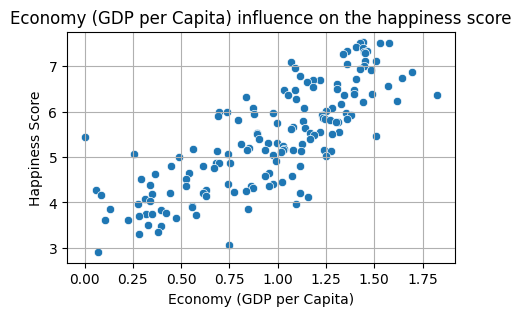

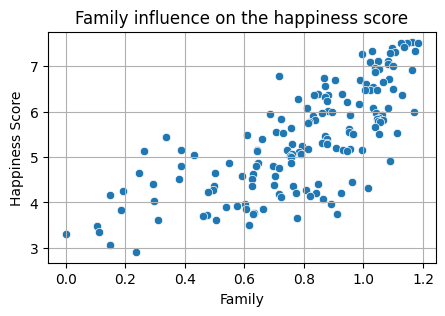

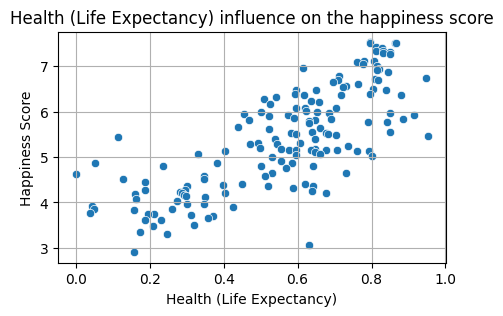

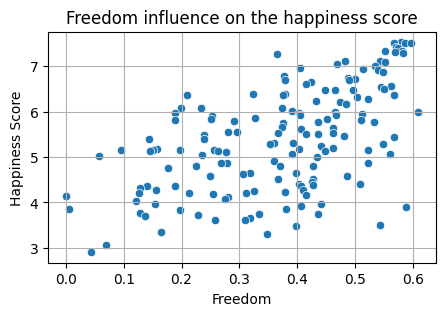

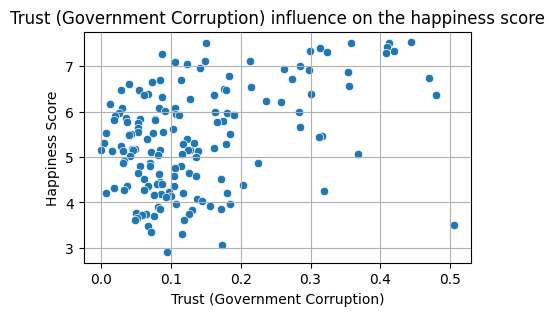

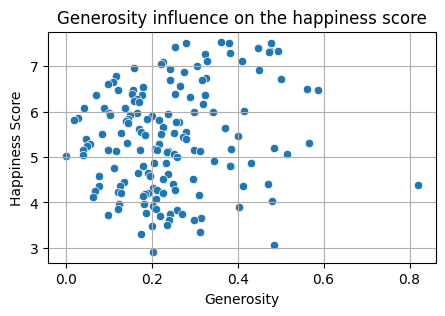

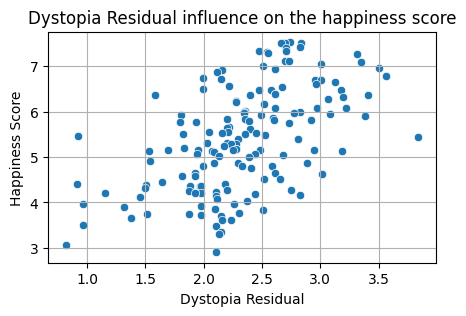

In [4]:
features = [
    'Economy (GDP per Capita)',
    'Family', 
    'Health (Life Expectancy)', 
    'Freedom',
    'Trust (Government Corruption)', 
    'Generosity',
    'Dystopia Residual'
]

for feature in features:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(data=df, x=feature, y='Happiness Score')
    plt.grid(True)
    plt.title(f'{feature} influence on the happiness score')
    plt.show()

---

### **Closed form**

Error:
0.6972626334828966
Final function:
y = [2.18686322]X + 3.296180041308007
Error:
0.00029323944326990363
Final function:
y = [0.99999088 1.00002422 0.99985263 1.00016829 0.99970066 1.00017439
 0.99994759]X + 0.0001357357434505694


Text(0, 0.5, 'Happiness Score')

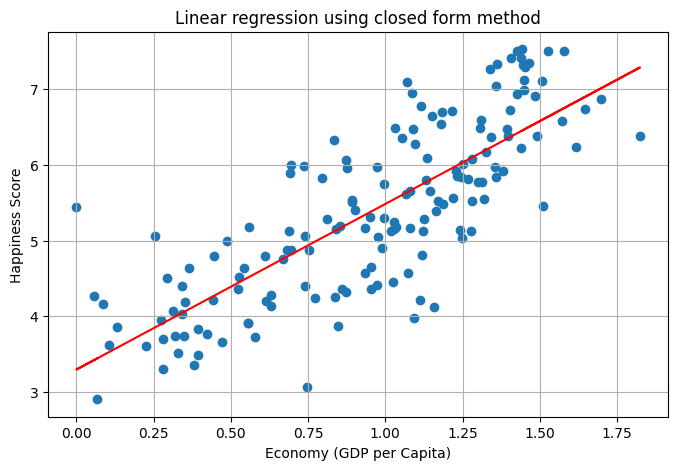

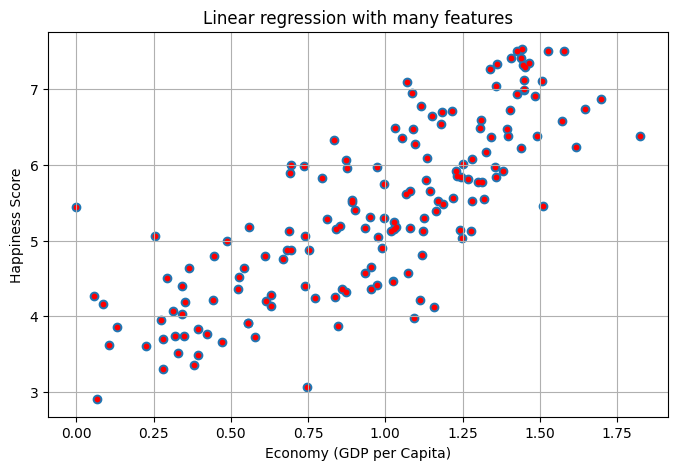

In [5]:
from closed_form import Linear_Regression_Closed_Form

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using closed form method')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

X = df[features].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

y_pred = closed_form.predict(X)

print(f'Error:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, label='Data')
plt.scatter(X[:, 0], y_pred, color='red', s=10, label='Prediction')
plt.grid(True)
plt.title('Linear regression with many features')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

---

### **Gradient descent**

RMSE: [4.7717537]
RMSE: [1.7619839]
RMSE: [0.93448289]
RMSE: [0.7874439]
RMSE: [0.76897972]
RMSE: [0.76685057]
RMSE: [0.7666028]
RMSE: [0.76656908]
RMSE: [0.76655984]
RMSE: [0.76655355]
RMSE: [0.76654778]
RMSE: [0.76654224]
RMSE: [0.76653689]
RMSE: [0.76653172]
RMSE: [0.76652673]
RMSE: [0.7665219]
RMSE: [0.76651724]
RMSE: [0.76651274]
RMSE: [0.76650839]
RMSE: [0.76650418]
RMSE: [0.76650012]
RMSE: [0.76649619]
RMSE: [0.7664924]
RMSE: [0.76648874]
RMSE: [0.7664852]
RMSE: [0.76648178]
RMSE: [0.76647847]
RMSE: [0.76647528]
RMSE: [0.76647219]
RMSE: [0.76646921]
RMSE: [0.76646633]
RMSE: [0.76646355]
RMSE: [0.76646086]
RMSE: [0.76645826]
RMSE: [0.76645575]
RMSE: [0.76645333]
RMSE: [0.76645098]
RMSE: [0.76644872]
RMSE: [0.76644653]
RMSE: [0.76644442]
RMSE: [0.76644238]
RMSE: [0.76644041]
RMSE: [0.7664385]
RMSE: [0.76643666]
RMSE: [0.76643488]
RMSE: [0.76643316]
RMSE: [0.7664315]
RMSE: [0.76642989]
RMSE: [0.76642834]
RMSE: [0.76642684]
RMSE: [0.7664254]
RMSE: [0.766424]
RMSE: [0.76642265]
RMSE:

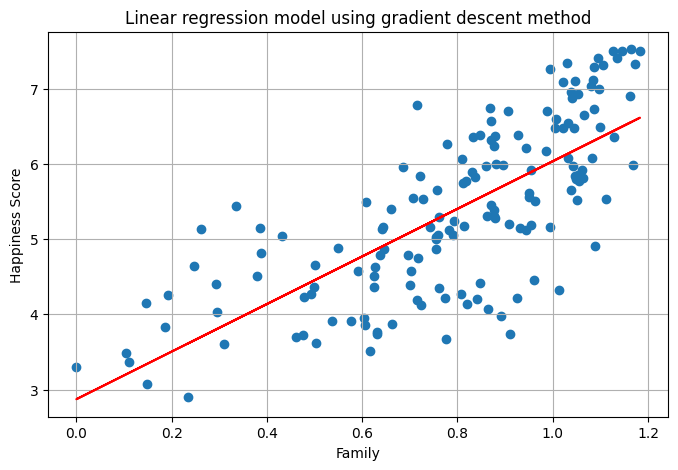

In [6]:
from gradient_descent import Linear_Regression_Gradient

X = df['Family'].to_numpy()
y = df['Happiness Score'].to_numpy()

gradient_descent = Linear_Regression_Gradient()

gradient_descent.fit(X, y, max_iters=1000, lr=0.2, stats=True)
y_pred = gradient_descent.predict(X)

print(f'Final function:\ny = {gradient_descent.weights}x + {gradient_descent.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Gradient descent')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using gradient descent method')
plt.grid()

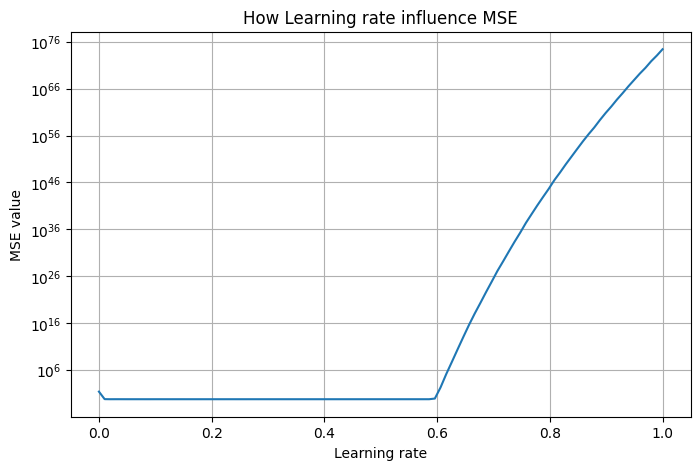

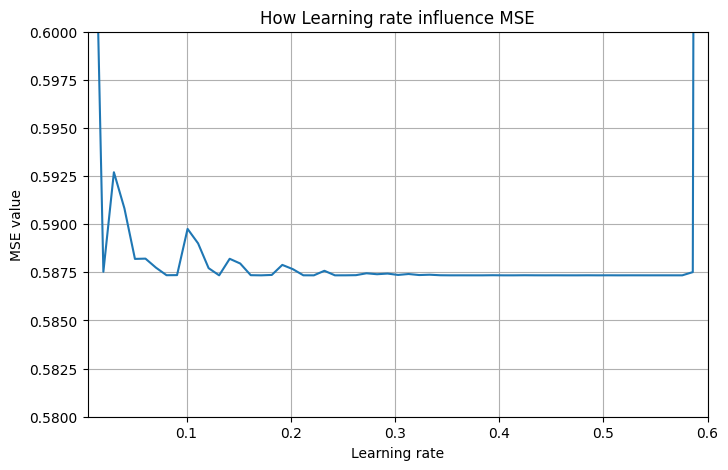

In [7]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Gradient()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0.005, 0.6)
plt.ylim(0.58, 0.6)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE')
plt.grid()


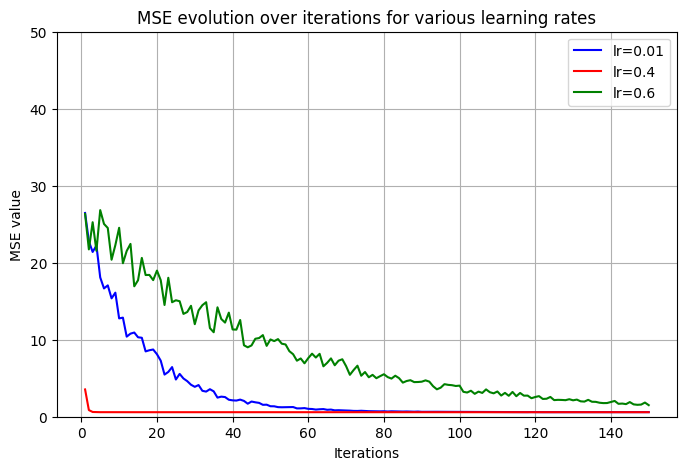

In [8]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.4, 0.6]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Gradient()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label='lr=0.01')
plt.plot(iterations, errors[1], color='red', label='lr=0.4')
plt.plot(iterations, errors[2], color ='green', label='lr=0.6')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Stochastic gradient descent**

RMSE: [0.12163944]
RMSE: [0.74631479]
RMSE: [0.94736034]
RMSE: [0.37345601]
RMSE: [0.19476627]
RMSE: [0.52267372]
RMSE: [0.06926945]
RMSE: [0.656277]
RMSE: [0.52413558]
RMSE: [0.99302904]
RMSE: [0.29403776]
RMSE: [0.14557534]
RMSE: [0.12127279]
RMSE: [0.66749896]
RMSE: [0.82206346]
RMSE: [0.75412919]
RMSE: [1.45433046]
RMSE: [0.64252258]
RMSE: [0.94640464]
RMSE: [1.08025114]
RMSE: [1.04501822]
RMSE: [0.78102789]
RMSE: [0.36861592]
RMSE: [0.96290566]
RMSE: [0.11255038]
RMSE: [0.52544262]
RMSE: [0.37515762]
RMSE: [0.43811459]
RMSE: [0.47734599]
RMSE: [0.65491104]
RMSE: [0.88954513]
RMSE: [0.8585565]
RMSE: [0.56765417]
RMSE: [0.39644321]
RMSE: [0.37758782]
RMSE: [1.15701088]
RMSE: [0.78360683]
RMSE: [0.4380322]
RMSE: [0.79364566]
RMSE: [0.51986014]
RMSE: [0.31023352]
RMSE: [1.22201339]
RMSE: [1.33130969]
RMSE: [0.15825482]
RMSE: [0.50882331]
RMSE: [0.41685995]
RMSE: [1.55126918]
RMSE: [0.28849035]
RMSE: [0.0249718]
RMSE: [0.33796122]
RMSE: [0.87066941]
RMSE: [1.0249877]
RMSE: [0.29076804]

Text(0.5, 1.0, 'Linear regression model using stochastic gradient descent method')

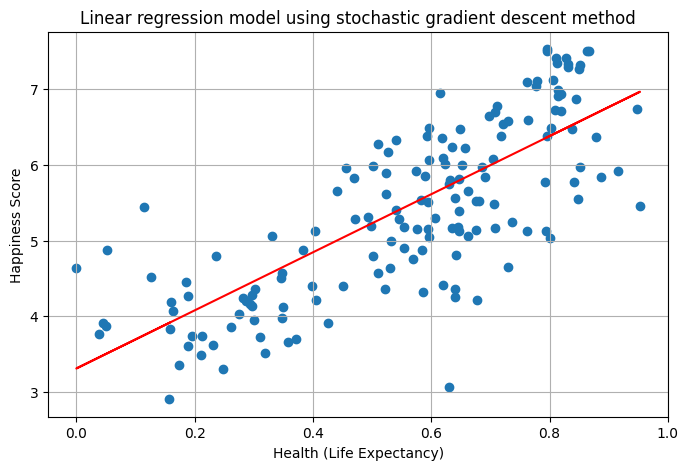

In [9]:
from stochastic_gd import Linear_Regression_Stochastic_GD

X = df['Health (Life Expectancy)'].to_numpy()
y = df['Happiness Score'].to_numpy()

stochastic = Linear_Regression_Stochastic_GD()
stochastic.fit(X, y, max_iters=100, lr=0.02, stats=True)

y_pred = stochastic.predict(X)

print(f'Final function\ny = {stochastic.weights}x + {stochastic.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Stochastic gradient descent')
plt.grid()
plt.xlabel('Health (Life Expectancy)')
plt.ylabel('Happiness Score')
plt.title('Linear regression model using stochastic gradient descent method')

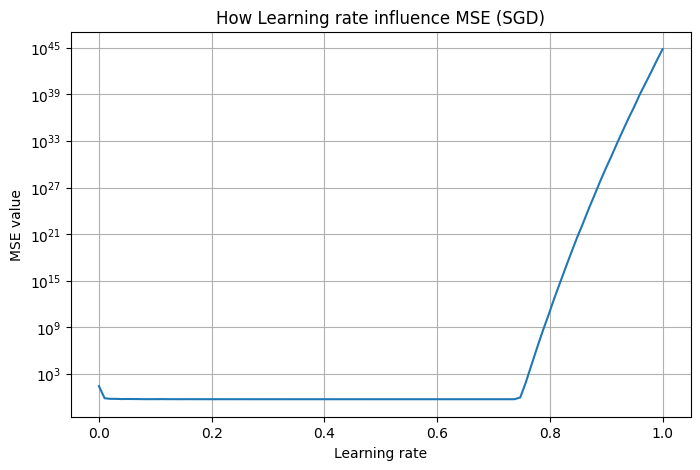

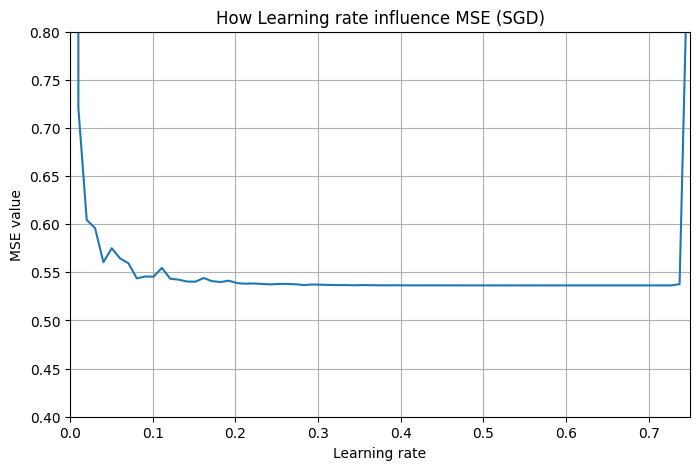

In [10]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Stochastic_GD()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.75)
plt.ylim(0.4, 0.8)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

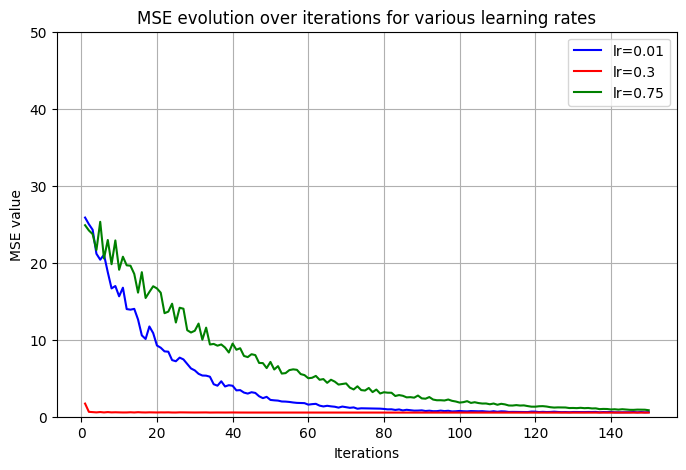

In [11]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.3, 0.75]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Stochastic_GD()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()


---

### **Mini batch**

RMSE: [1.0732533]
RMSE: [1.00534881]
RMSE: [1.03103326]
RMSE: [0.96536976]
RMSE: [0.97318842]
RMSE: [0.94173202]
RMSE: [0.80373632]
RMSE: [1.05372214]
RMSE: [1.10304731]
RMSE: [0.99756911]
RMSE: [0.89759649]
RMSE: [0.85003986]
RMSE: [1.01863645]
RMSE: [0.88260314]
RMSE: [0.99652432]
RMSE: [0.81781066]
RMSE: [0.94708424]
RMSE: [0.99691405]
RMSE: [1.08850515]
RMSE: [1.06609318]
RMSE: [0.91896027]
RMSE: [0.82121827]
RMSE: [0.76221773]
RMSE: [0.88171176]
RMSE: [0.99258138]
RMSE: [0.92642865]
RMSE: [0.97436908]
RMSE: [1.02072342]
RMSE: [0.82764564]
RMSE: [1.11000238]
RMSE: [1.03153938]
RMSE: [1.04909959]
RMSE: [0.96614646]
RMSE: [0.99957157]
RMSE: [0.95788737]
RMSE: [0.72152329]
RMSE: [0.78541485]
RMSE: [0.94156699]
RMSE: [0.93968203]
RMSE: [0.92942129]
RMSE: [0.99961237]
RMSE: [1.06971957]
RMSE: [0.94731372]
RMSE: [0.91456228]
RMSE: [0.87128862]
RMSE: [0.89655934]
RMSE: [1.08673291]
RMSE: [1.06159654]
RMSE: [0.93324742]
RMSE: [1.0121564]
RMSE: [1.03558631]
RMSE: [0.77358181]
RMSE: [0.90725

Text(0.5, 1.0, 'Linear regression using mini batch gradient descent method')

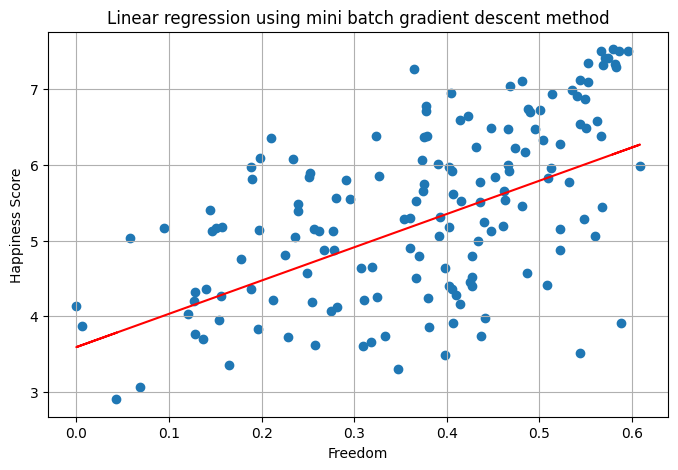

In [12]:
from mini_batch_gd import Linear_Regression_Mini_Batch

X = df['Freedom'].to_numpy()
y = df['Happiness Score'].to_numpy()

mini_batch = Linear_Regression_Mini_Batch()
mini_batch.fit(X, y, max_iters=100, lr=0.3, stats=True)

y_pred = mini_batch.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Mini batch gradient descent')
plt.grid()
plt.xlabel('Freedom')
plt.ylabel('Happiness Score')
plt.title('Linear regression using mini batch gradient descent method')

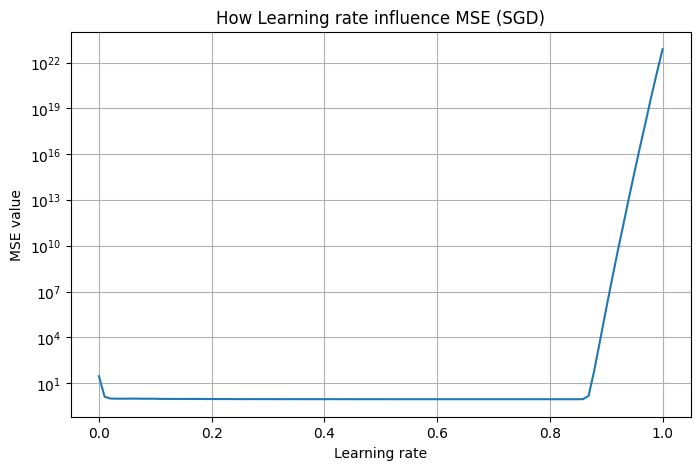

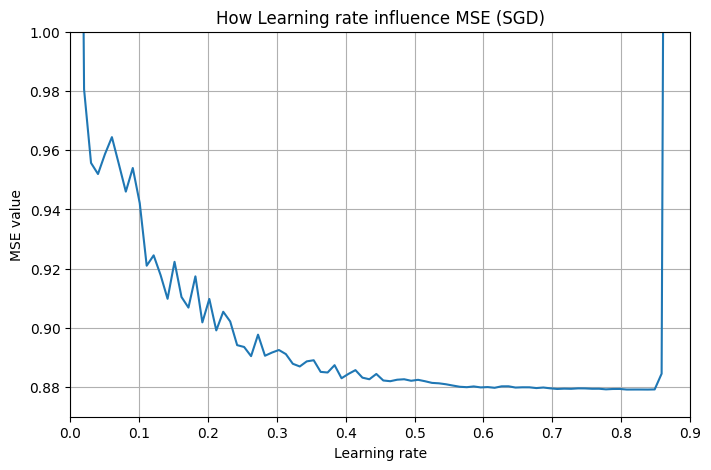

In [13]:
# === Learning rate test ===
learning_rate = np.linspace(0, 1, 100)
errors = []

for alpha in learning_rate:
    lr_test = Linear_Regression_Mini_Batch()
    gradient_descent.fit(X, y, max_iters=100, lr=alpha, stats=False)
    y_pred = gradient_descent.predict(X)

    errors.append(MSE(y, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.yscale('log')
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

plt.figure(figsize=(8, 5))
plt.plot(learning_rate, errors)
plt.xlim(0, 0.9)
plt.ylim(0.87, 1)
plt.xlabel('Learning rate')
plt.ylabel('MSE value')
plt.title('How Learning rate influence MSE (SGD)')
plt.grid()

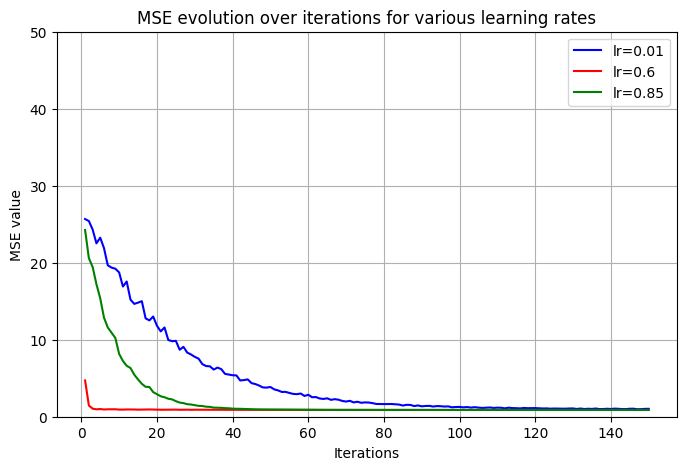

In [14]:
# === Iteration test ===
iterations = np.linspace(1, 150, 150, dtype=int)
learning_rate = [0.01, 0.6, 0.85]

errors = []
for alpha in learning_rate:
    error = []
    for iter in iterations:
        iter_test = Linear_Regression_Mini_Batch()
        gradient_descent.fit(X, y, max_iters=iter, lr=alpha, stats=False)
        y_pred = gradient_descent.predict(X)

        error.append(MSE(y, y_pred))
    errors.append(error)


plt.figure(figsize=(8, 5))
plt.plot(iterations, errors[0], color='blue', label=f'lr={learning_rate[0]}')
plt.plot(iterations, errors[1], color='red', label=f'lr={learning_rate[1]}')
plt.plot(iterations, errors[2], color ='green', label=f'lr={learning_rate[2]}')
plt.ylim(0, 50)
plt.xlabel('Iterations')
plt.ylabel('MSE value')
plt.title('MSE evolution over iterations for various learning rates')
plt.legend()
plt.grid()

---

### **Singular Value Decomposition (SVD)**

Final RMSE: [1.04201095]
Final Function: y = [[4.13362939]]x + [4.8132991]


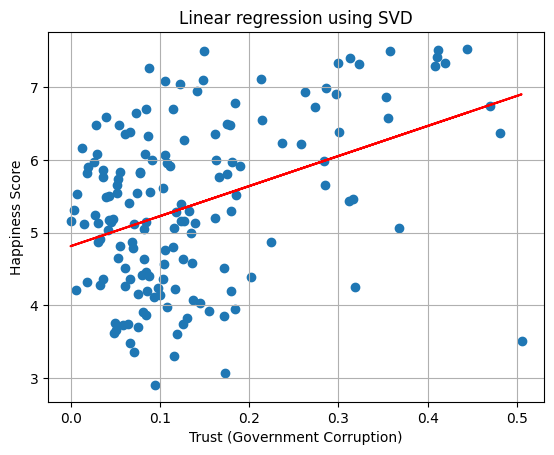

In [15]:
from svd import Linear_Regression_SVD

X = df['Trust (Government Corruption)'].to_numpy()
y = df['Happiness Score'].to_numpy()

svd = Linear_Regression_SVD()
svd.fit(X, y)

y_pred = svd.predict(X)

print(f'Final RMSE: {RMSE(y, y_pred)}')
print(f'Final Function: y = {svd.weights}x + {svd.bias}')
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='SVD')
plt.xlabel('Trust (Government Corruption)')
plt.ylabel('Happiness Score')
plt.title('Linear regression using SVD')
plt.grid()

Closed Form
Error:
0.6972626334828966
Final function:
y = [2.18686322]X + 3.296180041308007
SVD
Error:
[0.69726263]
Final function:
y = [[2.18686322]]X + [3.29618004]


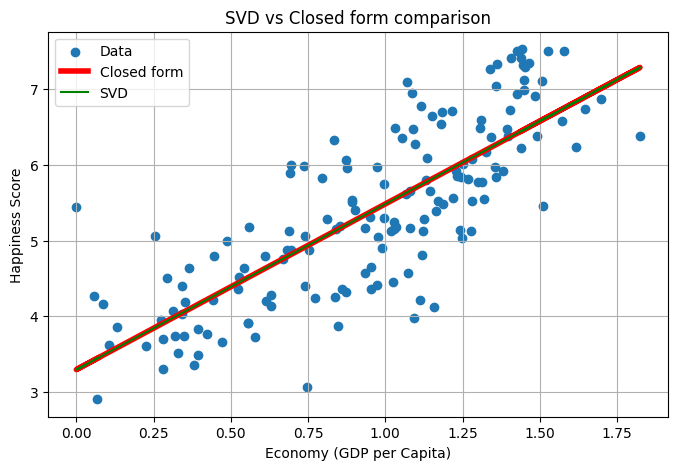

In [ ]:
# SVD vs Closed form comparison

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

closed_form = Linear_Regression_Closed_Form()
closed_form.fit(X, y)

svd = Linear_Regression_SVD()
svd.fit(X, y)

y_cf = closed_form.predict(X)
y_svd = svd.predict(X)

print('Closed Form')
print(f'Final RMSE:\n{RMSE(y, y_cf)}')
print(f'Final function:\ny = {closed_form.weights}X + {closed_form.bias}')


print('SVD')
print(f'Final RMSE:\n{RMSE(y, y_svd)}')
print(f'Final function:\ny = {svd.weights}X + {svd.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_cf, color='red', linewidth=4, label='Closed form')
plt.plot(X, y_svd, color='green', label='SVD')
plt.grid(True)
plt.title('SVD vs Closed form comparison')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend()


---

### **Ridge**

Final RMSE:
[0.69726263]
Final function:
y = [[2.18686322]]X + [3.29618004]


Text(0, 0.5, 'Happiness Score')

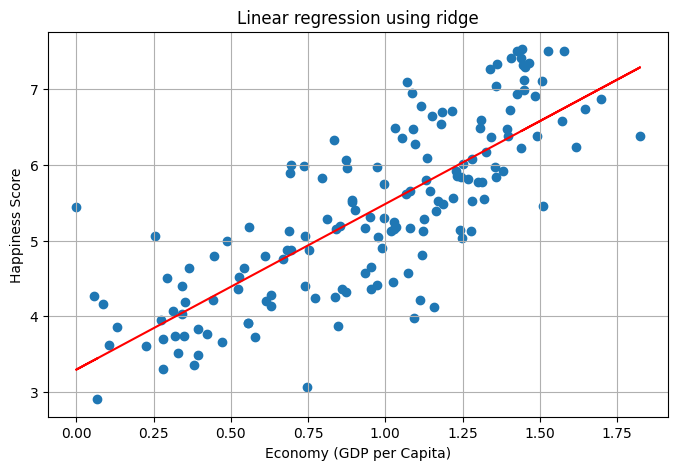

In [27]:
from ridge import Linear_Regression_Ridge

X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

ridge = Linear_Regression_Ridge()
ridge.fit(X, y, alpha=0)

y_pred = ridge.predict(X)

print(f'Final RMSE:\n{RMSE(y, y_pred)}')
print(f'Final function:\ny = {ridge.weights}X + {ridge.bias}')

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Closed form')
plt.grid(True)
plt.title('Linear regression using ridge')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')

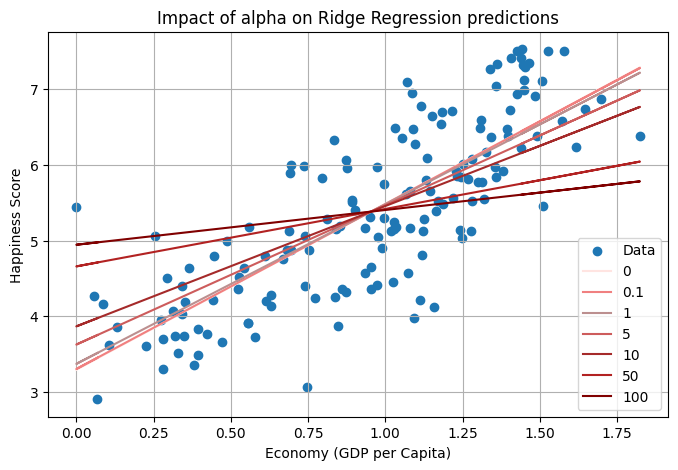

In [33]:
# === Alpha test ===
X = df['Economy (GDP per Capita)'].to_numpy()
y = df['Happiness Score'].to_numpy()

alphas = [0, 0.1, 1, 5, 10, 50, 100]
colors = [
    'mistyrose',
    'lightcoral',
    'rosybrown',
    'indianred',
    'brown',
    'firebrick',
    'maroon'
]

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data')

for alpha, color in zip(alphas, colors):
    ridge = Linear_Regression_Ridge()
    ridge.fit(X, y, alpha=alpha)

    y_pred = ridge.predict(X)

    plt.plot(X, y_pred, color=color, label=alpha)

plt.grid()
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.title("Impact of alpha on Ridge Regression predictions")
plt.legend()

---

### **Lasso**

---

### **Elastic net**

---

### **Polynomial regression**

---